# Modelo de clasificación de imágenes basado en una red neuronal profunda

Se pide utilizar el dataset que viene precargado en la librería Keras: [CIFAR10](https://keras.io/api/datasets/cifar10/)


1. Importa los módulos necesarios de la librería Keras. Sugerencia:


```
import numpy as np
from keras.models import Sequential
from keras.layers import Flatten, Dense
```



In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D
from keras.datasets import cifar10
from keras.utils import to_categorical
from matplotlib import pyplot as plt

2. Importa el dataset CIFAR10 de Keras, en un conjunto de datos de entrenamiento y un conjunto de datos para test. Sugerencia:


```
from keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```



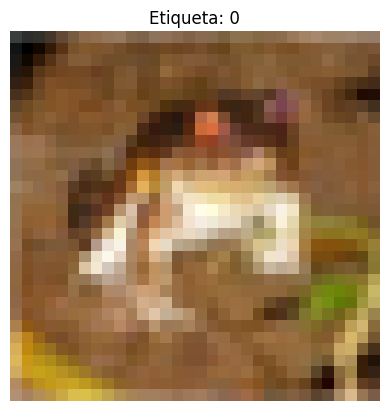

In [ ]:
# Importar el dataset de cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Mostrar primera imagen
plt.imshow(X_train[0])
plt.title(f"Etiqueta: {np.argmax(y_train[0])}")
plt.axis('off')
plt.show()

3. Explora los datos, especialmente, las dimensiones del dataset. Aplica normalización a los datos de entrada y la técnica one-hot encoding a los de salida.

*Sugerencia para normalizar:*


```
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train / 255.0
X_test = X_test / 255.0
```
*Sugerencia de aplicación one-hot encoding para categorizar etiquetas:*


```
# one hot encode outputs
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]
```




In [ ]:
# Normalización
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train / 255.0
X_test = X_test / 255.0

# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
num_classes = y_test.shape[1]

# Mostrar la estructura de datos con shape
print(X_train.shape)

(50000, 32, 32, 3)


4. Crea un modelo basado en redes neuronales profundas que tenga más de una capa de tipo Dense (Keras). Si es necesario, usa la capa Flatten al principio. Prueba un primer modelo lo más sencillo posible.

In [ ]:
# Construimos el modelo
model = Sequential([
    Input(shape=(32, 32, 3)),
    # Capas Convolucionales (Extraen características)
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # Aplanamos para clasificar
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

5. Configura el entrenamiento utilizando la función compile, con la función loss = 'categorical_crossentropy' y el optimizador Adam. Utiliza la función fit para entrenar el modelo, inicialmente, con 20 epochs.

In [ ]:
# Compilamos el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

# Resultado
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Pérdida en test: {loss:.4f}")
print(f"Precisión en test: {accuracy:.4f}")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.3851 - loss: 1.6728 - val_accuracy: 0.5662 - val_loss: 1.2195
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.6037 - loss: 1.1331 - val_accuracy: 0.6437 - val_loss: 1.0318
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6538 - loss: 0.9820 - val_accuracy: 0.6625 - val_loss: 0.9840
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 42ms/step - accuracy: 0.6788 - loss: 0.9194 - val_accuracy: 0.6791 - val_loss: 0.9349
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7023 - loss: 0.8535 - val_accuracy: 0.6824 - val_loss: 0.9256
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 43ms/step - accuracy: 0.7215 - loss: 0.8004 - val_accuracy: 0.6761 - val_loss: 0.9621
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.7381 - loss: 0.7574 - val_accuracy: 0.6877 - val_loss: 0.9266
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.7532 -

6. Crea un nuevo modelo con más capas y mayor número de neuronas. Entrénalo utilizando un número mayor de epochs y analiza el resultado. ¿Has conseguido mejorar la precisión? haz varias pruebas y quédate con el modelo que mejores resultados da.

In [ ]:
# Construimos el modelo
model2 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compilamos el modelo
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo
history2 = model2.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

# Resultado
loss, accuracy = model2.evaluate(X_test, y_test)
print(f"Pérdida en test: {loss:.4f}")
print(f"Precisión en test: {accuracy:.4f}")

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 151s 96ms/step - accuracy: 0.4041 - loss: 1.6201 - val_accuracy: 0.6193 - val_loss: 1.0898
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - accuracy: 0.6656 - loss: 0.9493 - val_accuracy: 0.6668 - val_loss: 0.9440
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 86ms/step - accuracy: 0.7370 - loss: 0.7498 - val_accuracy: 0.7190 - val_loss: 0.8122
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 84ms/step - accuracy: 0.7832 - loss: 0.6206 - val_accuracy: 0.7376 - val_loss: 0.7713
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 85ms/step - accuracy: 0.8231 - loss: 0.5016 - val_accuracy: 0.7332 - val_loss: 0.8006
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 85ms/step - accuracy: 0.8604 - loss: 0.3998 - val_accuracy: 0.7314 - val_loss: 0.8457
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - accuracy: 0.8920 - loss: 0.3042 - val_accuracy: 0.7314 - val_loss: 0.9293
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 86ms/step - accuracy: 

7. Utiliza el método evaluate para ver la precisión que se alcanzaría con datos nuevos, aplicándolo al conjunto de datos de test. ¿Es muy diferente a la precisión alcanzada en el entrenamiento?

In [ ]:

# Evaluación del modelo con el conjunto de test
loss, acc = model2.evaluate(X_test, y_test, verbose=0)

# Comparación de precisión: Entrenamiento vs Test
print(f"Precisión en Entrenamiento: {history2.history['accuracy'][-1]:.4f}")
print(f"Precisión en Test: {acc:.4f}")

# Respuesta a la pregunta:
# Si la precisión de entrenamiento es mucho mayor a la de test, hay overfitting.
# En este modelo (CIFAR-10 sin regularización), sí se observa un sobreajuste claro.

Precisión en Entrenamiento: 0.9846
Precisión en Test: 0.6977


8. Explora de forma visual la precisión que se consigue, representando las primeras 25 imágenes del conjunto de datos de test, y comparando la etiqueta real con la de la predicción. Aquí tienes una posible forma de hacerlo (recuerda poner el nombre de tu modelo a la hora de aplicar el método predict):


```
predictions = model.predict(X_test)

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid('off')
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    predicted_label = predictions[i]
    true_label = y_test[i]
    if predicted_label.argmax() == true_label.tolist().index(1.):
      color = 'green'
    else:
      color = 'red'
    plt.xlabel("{} ({})".format(class_names[predicted_label.argmax()],
                                  class_names[true_label.tolist().index(1.)]),
                                  color=color)
```



313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step


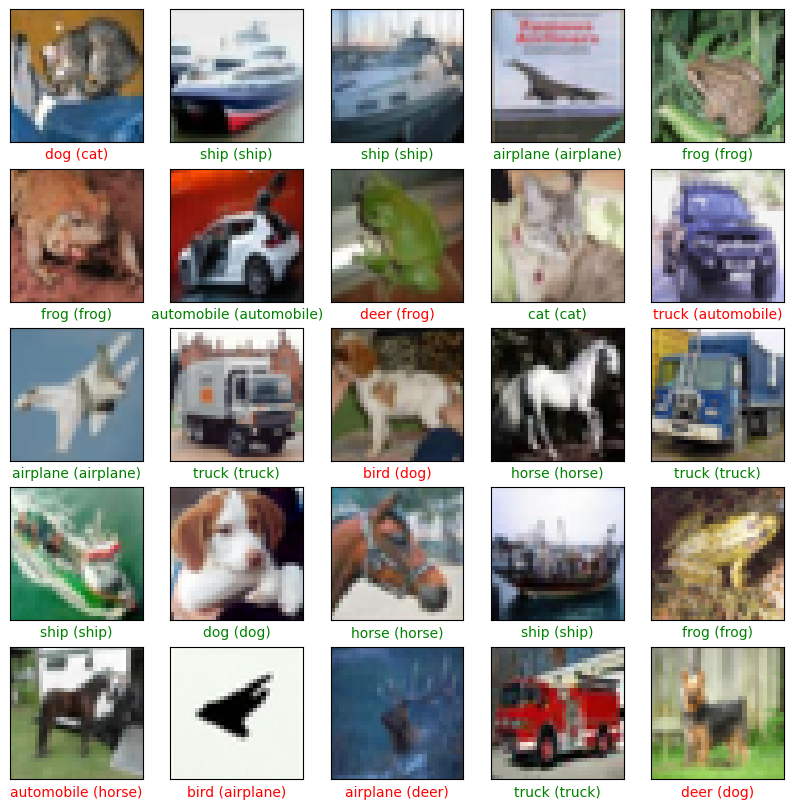

In [ ]:
predictions = model2.predict(X_test)

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid('off')
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    predicted_label = predictions[i]
    true_label = y_test[i]
    if predicted_label.argmax() == true_label.tolist().index(1.):
      color = 'green'
    else:
      color = 'red'
    plt.xlabel("{} ({})".format(class_names[predicted_label.argmax()],
                                  class_names[true_label.tolist().index(1.)]),
                                  color=color)